In [32]:
# ── Silence all LightGBM / MLflow / sklearn noise ──────────────────────────
import os, sys, warnings
os.environ["LIGHTGBM_VERBOSITY"] = "-1"
warnings.filterwarnings("ignore")

In [33]:
# ── Imports ─────────────────────────────────────────────────────────────────
import platform, optuna, mlflow, mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

In [34]:
# ── MLflow setup ─────────────────────────────────────────────────────────────
mlflow.set_tracking_uri('http://ec2-51-20-42-109.eu-north-1.compute.amazonaws.com:5000/')
mlflow.set_experiment("Exp 6.8")

<Experiment: artifact_location='s3://mlflow-bucket-1807077/19', creation_time=1773557147786, experiment_id='19', last_update_time=1773557147786, lifecycle_stage='active', name='Exp 6.8', tags={}>

In [35]:
# ── Load & clean data ────────────────────────────────────────────────────────
df = pd.read_csv("processed_data.csv")
df['clean_comment'] = df['clean_comment'].fillna('')
df = df[['clean_comment', 'category']]
df.head()

,clean_comment,category
0,family mormon never tried explain still stare ...,1
1,buddhism much lot compatible christianity espe...,1
2,seriously say thing first get complex explain ...,-1
3,learned want teach different focus goal not wr...,0
4,benefit may want read living buddha living chr...,1


In [36]:
# ── Remap labels & drop NaN ──────────────────────────────────────────────────
df['category'] = df['category'].map({-1: 2, 0: 0, 1: 1})
df = df.dropna(subset=['category'])

In [38]:
# ── TF-IDF  →  SMOTE  →  Train/Test split ───────────────────────────────────
vectorizer = TfidfVectorizer(ngram_range=(1, 3), max_features=1000)
X = vectorizer.fit_transform(df['clean_comment'])
y = df['category']

X_resampled, y_resampled = SMOTE(random_state=42).fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

In [39]:
trial_logs = []  # store metrics for plotting

def log_mlflow(model_name, model, X_train, X_test, y_train, y_test, params, run_label):
    with mlflow.start_run(run_name=f"{model_name}_trial_{run_label}"):

        stderr = sys.stderr
        sys.stderr = open(os.devnull, 'w')
        model.fit(X_train, y_train)
        sys.stderr = stderr

        # Train metrics
        y_train_pred = model.predict(X_train)
        y_train_prob = model.predict_proba(X_train)
        train_accuracy = accuracy_score(y_train, y_train_pred)
        train_loss     = log_loss(y_train, y_train_prob)

        # Test metrics
        y_test_pred = model.predict(X_test)
        y_test_prob = model.predict_proba(X_test)
        test_accuracy = accuracy_score(y_test, y_test_pred)
        test_loss     = log_loss(y_test, y_test_prob)

        lr = params.get('learning_rate', 'N/A')

        mlflow.log_params(params)
        mlflow.log_metric("train_accuracy", train_accuracy)
        mlflow.log_metric("test_accuracy",  test_accuracy)
        mlflow.log_metric("train_loss",     train_loss)
        mlflow.log_metric("test_loss",      test_loss)
        mlflow.sklearn.log_model(model, name=model_name)

        # Save for plotting
        if run_label != "Best":
            trial_logs.append({
                "trial":          run_label,
                "train_accuracy": train_accuracy,
                "test_accuracy":  test_accuracy,
                "train_loss":     train_loss,
                "test_loss":      test_loss,
            })

        print(f"Trial {run_label:>4} | LR: {lr:.6f} | "
              f"Train Acc: {train_accuracy:.4f} | Test Acc: {test_accuracy:.4f} | "
              f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")

    return test_accuracy

In [45]:
# ── Optuna objective ─────────────────────────────────────────────────────────
def objective_lightgbm(trial):
    params = {
        'n_estimators':      trial.suggest_int  ('n_estimators',      800,  1000),
        'learning_rate':     trial.suggest_float('learning_rate',      3e-2, 1e-1, log=True),
        'max_depth':         trial.suggest_int  ('max_depth',          3,    15),
        'num_leaves':        trial.suggest_int  ('num_leaves',         20,   150),
        'min_child_samples': trial.suggest_int  ('min_child_samples',  10,   100),
        'reg_alpha':  trial.suggest_float('reg_alpha',  0.1,  5.0, log=True),  # was 1e-4 to 10
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1,  5.0, log=True),  # was 1e-4 to 10
        'subsample':  trial.suggest_float('subsample',  0.6,  0.8),            # was 0.5 to 1.0
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.8), # was 0.5 to 1.0
        'min_gain_to_split': trial.suggest_float('min_gain_to_split', 0.1, 1.0),
    }

    model = LGBMClassifier(**params, random_state=42, verbose=-1)
    return log_mlflow("LightGBM", model, X_train, X_test, y_train, y_test, params, trial.number)

In [ ]:
# ── Run Optuna with early stopping ───────────────────────────────────────────
def early_stopping(study, trial, window=15):
    if trial.number >= window:
        best_recent = max(t.value for t in study.trials[-window:] if t.value is not None)
        if best_recent <= study.best_value - 1e-6:
            print(f"\n⛔ Early stopping at trial {trial.number} — no improvement in last {window} trials.")
            study.stop()

optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(direction="maximize")
study.optimize(objective_lightgbm, n_trials=100, callbacks=[early_stopping])

# ── Log best model ───────────────────────────────────────────────────────────
best_model = LGBMClassifier(**study.best_params, random_state=42, verbose=-1)
log_mlflow("LightGBM", best_model, X_train, X_test, y_train, y_test, study.best_params, "Best")

# # ── Plots ────────────────────────────────────────────────────────────────────
# optuna.visualization.plot_param_importances(study).show()
# optuna.visualization.plot_optimization_history(study).show()

Trial    0 | LR: 0.045563 | Train Acc: 0.8568 | Test Acc: 0.8021 | Train Loss: 0.4268 | Test Loss: 0.5349
🏃 View run LightGBM_trial_0 at: http://ec2-51-20-42-109.eu-north-1.compute.amazonaws.com:5000/#/experiments/19/runs/adb795ffee8f41a2a0b7e9934ab7a5cc
🧪 View experiment at: http://ec2-51-20-42-109.eu-north-1.compute.amazonaws.com:5000/#/experiments/19
Trial    1 | LR: 0.078527 | Train Acc: 0.8348 | Test Acc: 0.7938 | Train Loss: 0.4784 | Test Loss: 0.5586
🏃 View run LightGBM_trial_1 at: http://ec2-51-20-42-109.eu-north-1.compute.amazonaws.com:5000/#/experiments/19/runs/a87d3a7a73374879906c98b834d07439
🧪 View experiment at: http://ec2-51-20-42-109.eu-north-1.compute.amazonaws.com:5000/#/experiments/19
Trial    2 | LR: 0.033568 | Train Acc: 0.8063 | Test Acc: 0.7798 | Train Loss: 0.5766 | Test Loss: 0.6164
🏃 View run LightGBM_trial_2 at: http://ec2-51-20-42-109.eu-north-1.compute.amazonaws.com:5000/#/experiments/19/runs/7e61a35275bd4066a02bbfd88542ce32
🧪 View experiment at: http://ec2-

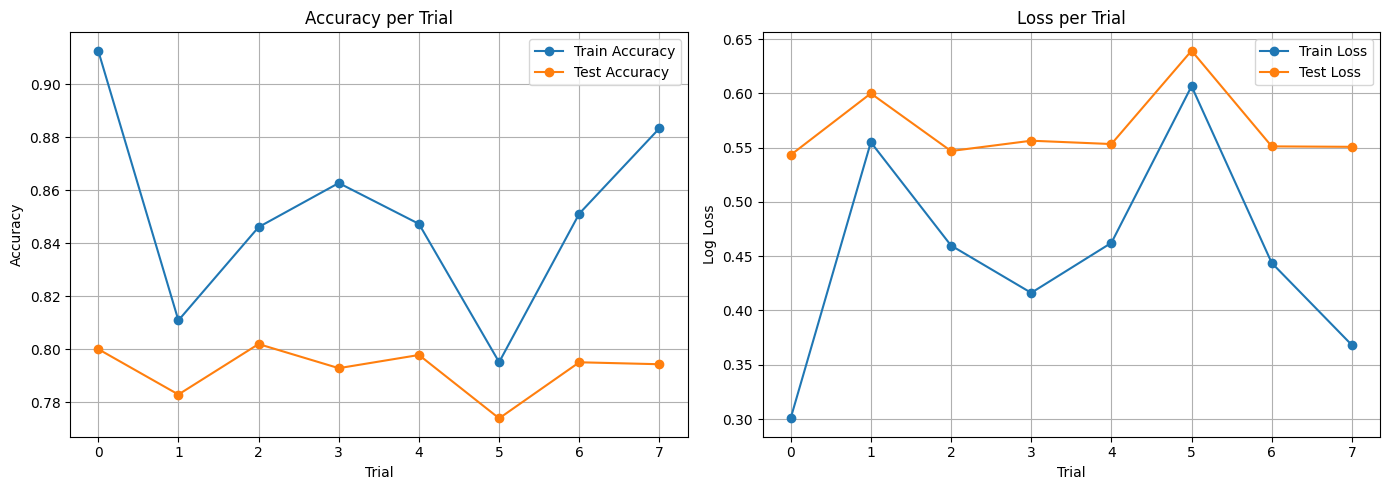

In [ ]:
import matplotlib.pyplot as plt

df_logs = pd.DataFrame(trial_logs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(df_logs["trial"], df_logs["train_accuracy"], label="Train Accuracy", marker='o')
ax1.plot(df_logs["trial"], df_logs["test_accuracy"],  label="Test Accuracy",  marker='o')
ax1.set_title("Accuracy per Trial")
ax1.set_xlabel("Trial")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(df_logs["trial"], df_logs["train_loss"], label="Train Loss", marker='o')
ax2.plot(df_logs["trial"], df_logs["test_loss"],  label="Test Loss",  marker='o')
ax2.set_title("Loss per Trial")
ax2.set_xlabel("Trial")
ax2.set_ylabel("Log Loss")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()